# 3- Exploring some of the features to be used

- Fixations: count, duration (mean/std/max/min)
- Saccades: count, peak_veocity, amplitude (mean/max/min/std), duration (mean/std/max/min)
- Blinks: count, mean duration
- Pupil: LHIPA 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import cognitive_models.preprocessing as cwpre
import cognitive_models.features as cwfeat
import cognitive_models.interpolate as cwinterp
import cognitive_models.pupil_utils as cwpupil
from importlib import reload
reload(cwpupil)
reload(cwinterp)
reload(cwpre)
reload(cwfeat)

COLET_DATASET_DIR = Path(cwpre.__file__).parents[2] / "datasets" / "COLET_CSV"
PARTICIPANTS = list(range(1, 11)) # Participants 1 to 10
PARTICIPANTS.remove(6) # Bad data
EXPERIMENTS = [1,2,3,4]

### A. Getting all the needed features

In [2]:
# 1- Load all required data
all_eye_data = cwpre.load_colet_data(COLET_DATASET_DIR, PARTICIPANTS, EXPERIMENTS)

print(f"Loaded eye-tracking data for {len(PARTICIPANTS)} participants and {len(EXPERIMENTS)} experiments. Total records: {len(all_eye_data)}")

There are 1 non matching timestamp_sec within the limits
Final merged dataset has 8184 records at 240 Hz
Final merged and resampled dataset has 2028 records at 60 Hz
There are 1 non matching timestamp_sec within the limits
Final merged dataset has 6866 records at 240 Hz
Final merged and resampled dataset has 1709 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 17301 records at 240 Hz
Final merged and resampled dataset has 4285 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 9246 records at 240 Hz
Final merged and resampled dataset has 2290 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 10159 records at 240 Hz
Final merged and resampled dataset has 2505 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 7113 records at 240 Hz
Final merged and resampled dataset has 1769 records at 60 Hz
Th

In [3]:
# Lets check integrity of the data
all_eye_data.columns
all_eye_data.groupby(['subject_id', 'task_id'])['cl_class'].value_counts().sort_index().head()

subject_id  task_id  cl_class
1           1        low         2028
            2        medium      1709
            3        high        4285
            4        medium      2290
2           1        low         2505
Name: count, dtype: int64

In [5]:
import tqdm
all_eye_data_grouped = all_eye_data.groupby(['subject_id', 'task_id'])
# Extract all window features
Fs = 60
WINDOW_N = 512
WINDOW_STEP = 64
SKIP_EDGE_SAMPLES = Fs # first & last 2 seconds are discarded

features_df = pd.DataFrame()
for (subject_id, task_id), group_df in tqdm.tqdm(all_eye_data_grouped, desc="Extracting features"):
    feature_rows = []
    # Discard edge samples
    group_df = group_df.iloc[SKIP_EDGE_SAMPLES:-SKIP_EDGE_SAMPLES].sort_values('timestamp_sec')
    
    # Extract features in sliding windows
    for start in range(WINDOW_N, len(group_df), WINDOW_STEP):
        window_df = group_df.iloc[start - WINDOW_N:start].reset_index(drop=True)
        window_df, blink_df = cwpre.preprocess_colet_data(window_df, verbose=False) # Add derived columns
        features = cwfeat.extract_window_features(window_df, blink_df, ivt_threshold=45, min_fixation_duration=55, verbose=False)
        features['subject_id'] = subject_id
        features['task_id'] = task_id
        features['cl_class'] = window_df['cl_class'].iloc[0] # Class is the same for a given task
        feature_rows.append(features)
    
    features_df = pd.concat([features_df, pd.DataFrame(feature_rows)], ignore_index=True)

print(f"Extracted features for {len(features_df)} windows.")

Extracting features: 100%|██████████| 36/36 [04:07<00:00,  6.88s/it]

Extracted features for 1213 windows.


In [6]:
# Check what is the issue with the NaNs
features_df[features_df.isna().any(axis=1)].head()

,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_std,saccades_count,saccades_peak_velocity_mean,saccades_amplitude_mean,saccades_amplitude_max,saccades_amplitude_min,...,saccades_duration_mean,saccades_duration_max,saccades_duration_min,saccades_duration_std,blinks_count,blinks_duration_mean,pupil_lhipa,subject_id,task_id,cl_class


Let's check the distribtuion of the label classes 

<Axes: title={'center': 'Distribution of classes'}, xlabel='Cognitive Load Class', ylabel='Number of windows'>

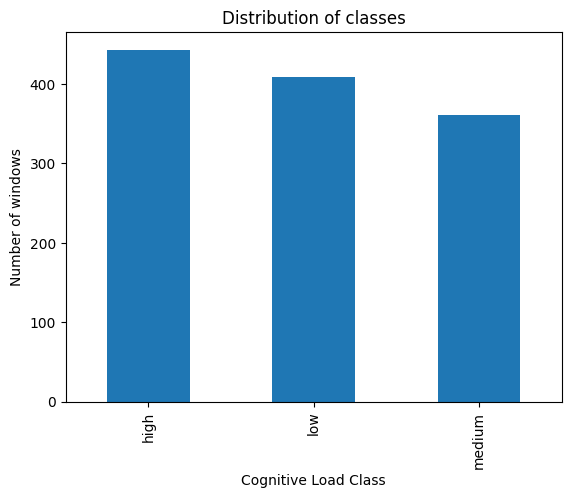

In [12]:
features_df.groupby('cl_class').count().plot(kind='bar', y='subject_id', title="Distribution of classes", legend=False, ylabel="Number of windows", xlabel="Cognitive Load Class")

As one can see, classes look quite balanced, which is a good thing for training a classifier

Now let's explore the distribution of the LHIPA metric.

As a reminder, it is related to a count of the number of spike/sec over the defined time window

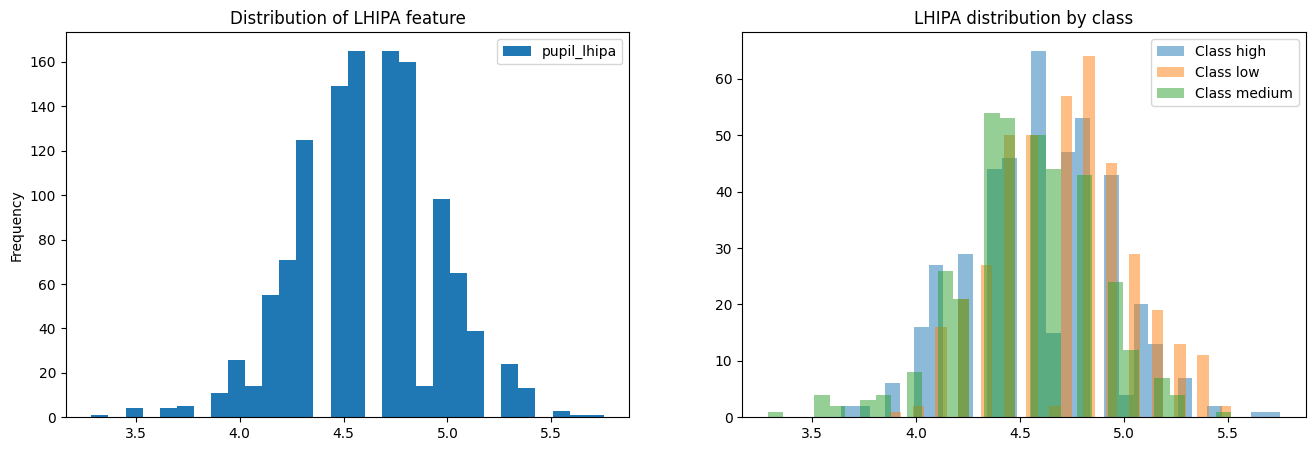

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
features_df.plot(y='pupil_lhipa', kind='hist', bins=30, title='Distribution of LHIPA feature', ax=axs[0])
grouped_df = features_df.groupby('cl_class')
for cl_class, group in grouped_df:
    axs[1].hist(group['pupil_lhipa'], bins=30, alpha=0.5, label=f'Class {cl_class}')
axs[1].set_title('LHIPA distribution by class')
axs[1].legend()

<Axes: title={'center': 'pupil_lhipa'}, xlabel='Cognitive Load Class', ylabel='LHIPA'>

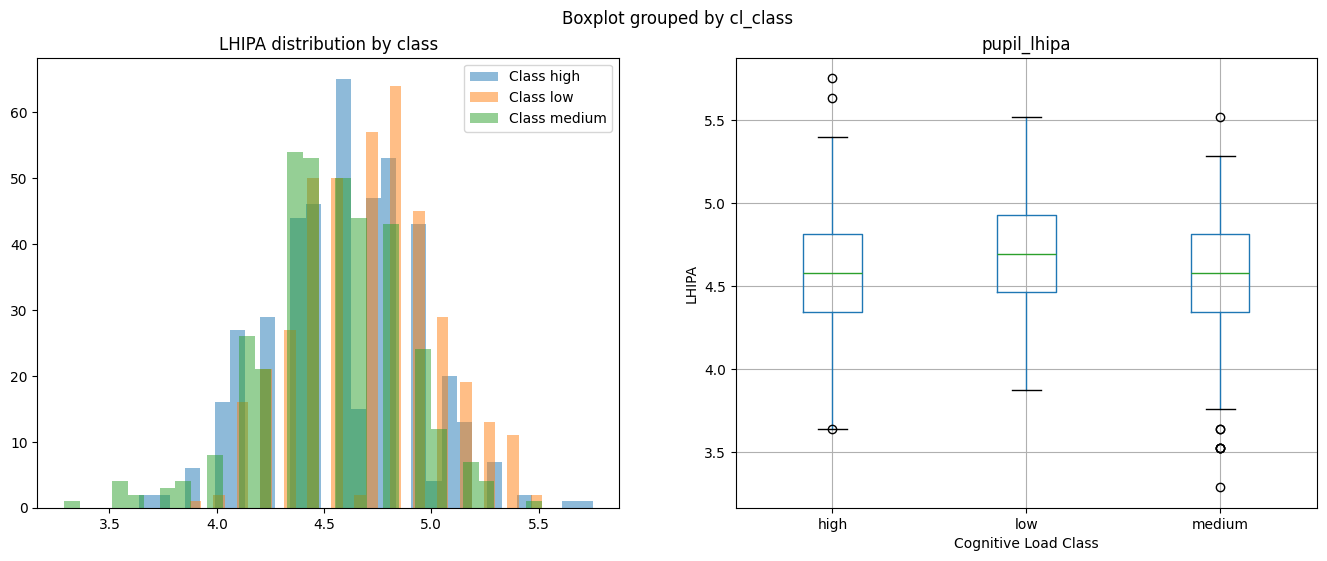

In [41]:
# Have box plots for the 3 classes on the same plot (x axis is class, y axis is LHIPA)
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
grouped_df = features_df.groupby('cl_class')
for cl_class, group in grouped_df:
    axs[0].hist(group['pupil_lhipa'], bins=30, alpha=0.5, label=f'Class {cl_class}')
axs[0].legend()
axs[0].set_title('LHIPA distribution by class')
features_df.boxplot(column='pupil_lhipa', by='cl_class', ax=axs[1], ylabel='LHIPA', xlabel='Cognitive Load Class')


In [46]:
# Lets perform a ttest to see if the difference in LHIPA between classes is significant
from scipy.stats import ttest_ind
class_0 = features_df[features_df['cl_class'] == 'low']['pupil_lhipa']
class_1 = features_df[features_df['cl_class'] == 'medium']['pupil_lhipa']
class_2 = features_df[features_df['cl_class'] == 'high']['pupil_lhipa']
print(f"Number of windows in low class: {len(class_0)}, medium class: {len(class_1)}, high class: {len(class_2)}")
t_stat, p_value = ttest_ind(class_0, class_1, equal_var=False)
print(f"T-test between low and medium classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")
t_stat, p_value = ttest_ind(class_0, class_2, equal_var=False)
print(f"T-test between low and high classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")
t_stat, p_value = ttest_ind(class_1, class_2, equal_var=False)
print(f"T-test between medium and high classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")

Number of windows in low class: 409, medium class: 361, high class: 443
T-test between low and medium classes: t-statistic=7.795, p-value=0.00000
T-test between low and high classes: t-statistic=5.166, p-value=0.00000
T-test between medium and high classes: t-statistic=-2.830, p-value=0.00478
